# Tweet Classification: Real Disaster or Not?

Building a text classifier for tweets. The data comes from the Kaggle competition ["Real or Not? NLP with Disaster Tweets"](https://www.kaggle.com/competitions/nlp-getting-started/data) -- I'm using the `train.csv` file from there, split into train/test with the code below.

Working with a dataset of tweets. This is a binary classification problem: predict whether a tweet is actually about a real disaster/incident or not.

In [21]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [11]:
data = pd.read_csv('https://raw.githubusercontent.com/murodzodam01/Machine-Learning-Projects/refs/heads/main/NLP%20Classification/train.csv?token=GHSAT0AAAAAAEHRAZDGXAZBKGUXX7235YIE2UYXJTA')

In [12]:
data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

Print info on missing values in the data. If there are any, fill them with an empty string.

In [14]:
from sklearn.impute import SimpleImputer
if train.isnull().any().any()==1 or test.isnull().any().any()==1:
    print('Missing values present')
else:
    print('No missing values')

cat_features_mask = (train.dtypes == "object").values # categorical features have dtype "object"
train_real = train[train.columns[~cat_features_mask]]
train = train[train.columns[cat_features_mask]].fillna("")
train = pd.concat([train_real, train], axis=1)

cat_features_mask = (test.dtypes == "object").values # categorical features have dtype "object"
test_real = test[test.columns[~cat_features_mask]]
test = test[test.columns[cat_features_mask]].fillna("")
test = pd.concat([test_real, test], axis=1)

Missing values present


Let's take a look at the data. Visualize (where explicitly asked) or print info on the following:

1. What's the class distribution in the training set?
2. Look at the "keyword" column -- take the 10 most common values, plot a step chart of the class distribution against keyword value, and draw some conclusions.

In [15]:
print('Positive class:', train['target'].sum())
print('Negative class:', train.shape[0] - train['target'].sum())

Positive class: 2305
Negative class: 3024


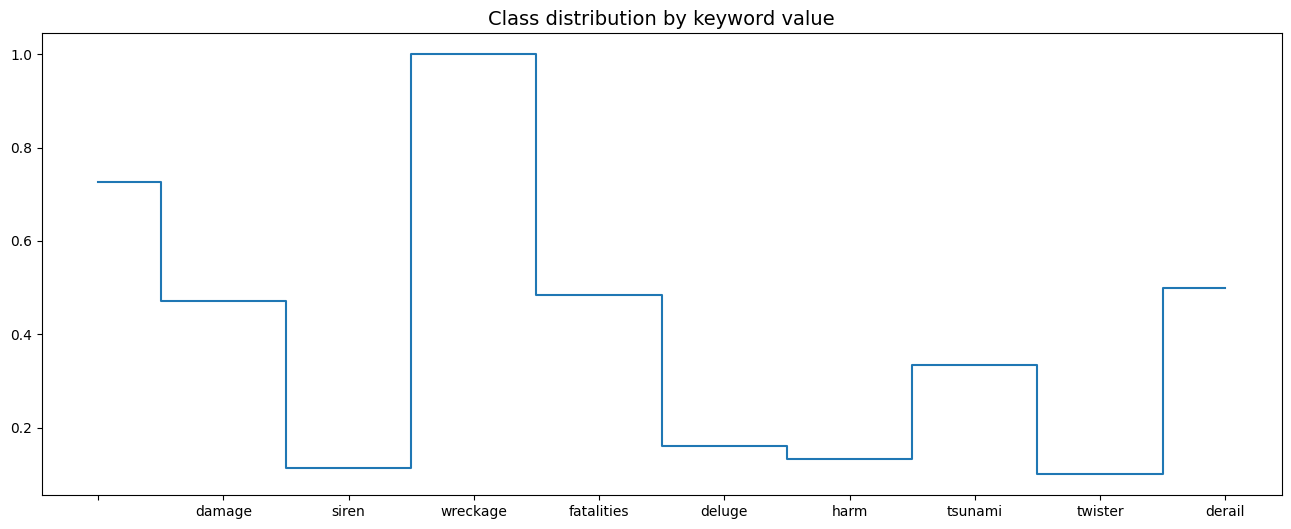

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
ten_common_words=dict(train['keyword'].value_counts()[:10])
nu = []
labels = []
for elem in ten_common_words.keys():
    labels.append(elem)
    nu.append(((train['keyword']==elem) & (train['target']==1)).sum()/ten_common_words[elem])
index = np.arange(10)
bw = 0.1
fig,ax = plt.subplots(figsize=[16,6])
ax.set_title('Class distribution by keyword value', fontsize=14)
ax.step(labels, nu, where='mid')

plt.show()

Merge all three text columns into one (just concatenate the strings), and drop the index column.

In [17]:
test['new'] = test['keyword']  + ' ' + test['location'] + ' ' + test['text']
train['new'] = train['keyword']  + ' ' + train['location'] + ' ' + train['text']
train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)

For now I'll work only with the train part.

1. Preprocess the data (train part) with CountVectorizer.
2. What size is the resulting matrix?

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
cnt_vec = CountVectorizer()
X = cnt_vec.fit_transform(train['new'])
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 86671 stored elements and shape (5329, 18455)>

Vocabulary that `CountVectorizer` built -- it's available in the `vocabulary_` attribute of a fitted instance. Function that prints answers to the following:

1. Find every word in the vocabulary that contains digits. How many are there?
2. Find every word that contains punctuation characters. How many are there?
3. How many hashtags (tokens starting with #) and mentions (tokens starting with @) are left in the vocabulary?

In [22]:
import re
def some_func(some_dict):
    pattern_digit = re.compile('\d+')
    list_digit = []
    pattern_punkt = re.compile('[^\w\s]|[_]')
    list_punkt = []
    pattern_other = re.compile('^[#@]')
    list_other = []
    for elem in some_dict.keys():
        if pattern_digit.findall(elem):
            list_digit.append(elem)
        if pattern_punkt.findall(elem):
            list_punkt.append(elem)
        if pattern_other.findall(elem):
            list_other.append(elem)
    return list_digit, list_punkt, list_other
some_dict = cnt_vec.vocabulary_
list_digit, list_punkt, list_other = some_func(some_dict)
print('Words in the vocabulary containing digits =', len(list_digit))
print(list_digit)
print()
print('_'*75)
print('Words in the vocabulary containing punctuation =', len(list_punkt))
print(list_punkt)
print()
print('_'*75)
print('Words in the vocabulary starting with # or @ =', len(list_other))
print(list_other)

Words in the vocabulary containing digits = 3812
['20collapse', '2015', '60', 't5trhjuau0', 'b1g', 'bmurph1019', 'termn8r13', 'oaskgki6qj', 'di8elzswnr', '20accident', 'tagzbcxfj0', 'xxfk4khbiw', 'mkx6ux4ozt', 'ma4ra7atql', 'cg579wldne', '7xglah10zl', 'musbik7ejf', '20bag', '35', '23', '419', 'hcdiwe5flc', 'roughdeal1', '65', '11', '20bombing', 'jackmulholland1', 'czdw8oowa2', 'zl7ojdaj3u', 'lkjfabqzb3', '20burning', '1acd4900c1424d1', '20fires', 'ns1aggfnxz', '3m', 'od250zshfy', 'wd9odwjj9l', '20on', '20fire', 'tweetlikeitsseptember11th2001', '20spill', 'ks100', '7o4lnfbe7k', '20responders', 'tl93aod3er', '20', 'obix79ncxn', 'z8r6r3nbtb', 'namffldh5h', '53inch', '300w', '4x4', 'o097vsotxk', 'i23xy7iejj', '00', '06', 'thhjjw51pe', '01', '325ci', '5l', 'l6', 'c211hise0r', '10', 'xbznu0qkvs', 'jlczidz7vu', 'mylittlepwnies3', '80s', 'lhw4vtbhzg', 'yh5vetm0yz', '17wgug8z0m', '073izwx0lb', '18', 'e7fn5g5ruu', '75k', '52k', 'shhlv4dplz', '20storm', 'sf5jdnvdw9', '20wave', 'k9airfq3ql', '20re

`nltk` has a tokenizer built specifically for tweets -- `TweetTokenizer`. Let's try `CountVectorizer` with it instead. Answer for the same three questions from the previous step for `TweetTokenizer` and compare the results.

In [23]:
from nltk.tokenize import TweetTokenizer
from nltk.tokenize import word_tokenize
# To see what parameters this tokenizer takes, use help(TweetTokenizer)
# To pass a tokenizer into CountVectorizer, use the tokenizer parameter

In [24]:
def func_tok(smth):
    elem = TweetTokenizer()
    return elem.tokenize(smth)
cnt_vec = CountVectorizer(tokenizer=func_tok)
X = cnt_vec.fit_transform(train['new'])
list_digit, list_punkt, list_other=some_func(cnt_vec.vocabulary_)
print('Words in the vocabulary containing digits =', len(list_digit))
print(list_digit)
print('_'*75)
print()
print('Words in the vocabulary containing punctuation =', len(list_punkt))
print(list_punkt)
print('_'*75)
print()
print('Words in the vocabulary starting with # or @ =', len(list_other))
print(list_other)

Words in the vocabulary containing digits = 3939
['20collapse', '2015', '60', 'http://t.co/t5trhjuau0', 'b1g', '@bmurph1019', '@termn8r13', 'http://t.co/oaskgki6qj', 'http://t.co/di8elzswnr', '20accident', 'http://t.co/tagzbcxfj0', 'http://t.co/xxfk4khbiw', 'https://t.co/mkx6ux4ozt', 'https://t.co/ma4ra7atql', 'http://t.co/cg579wldne', 'http://t.co/7xglah10zl', 'https://t.co/musbik7ejf', '2', '20bag', '35', '7.23', '419-3', 'http://t.co/hcdiwe5flc', '@roughdeal1', '65', '11', '20bombing', '@jackmulholland1', 'https://t.co/czdw8oowa2', 'http://t.co/zl7ojdaj3u', '6', 'http://t.co/lkjfabqzb3', '20burning', '@1acd4900c1424d1', '20fires', 'http://t.co/ns1aggfnxz', '2.0', '3m', 'http://t.co/od250zshfy', 'http://t.co/wd9odwjj9l', '20on', '20fire', '#tweetlikeitsseptember11th2001', '20spill', 'ks100', 'http://t.co/7o4lnfbe7k', '20responders', 'http://t.co/tl93aod3er', '20', 'http://t.co/obix79ncxn', 'http://t.co/z8r6r3nbtb', 'http://t.co/namffldh5h', '53inch', '300w', '4x4', 'http://t.co/o097v

Comparing the results, TweetTokenizer does a good job of picking out usernames and account links (since they contain punctuation). For the first question the two tokenizers find roughly the same number of words, but TweetTokenizer clearly does better on the second and third questions -- not surprising given
what it's designed for.

`scikit-learn` lets us customize how `CountVectorizer` builds the matrix. Like other `_VectorizerMixin` subclasses, it takes `tokenizer` and `preprocessor` arguments -- `preprocessor` is applied to each row of the dataset first, and `tokenizer` takes a string and returns tokens.

Let's write a custom tokenizer that does everything I need:

0. Lowercases everything
1. Splits text into tokens using `TweetTokenizer` from `nltk`
2. Drops any tokens containing non-Latin characters, except emoticons (tokens that consist only of punctuation and contain at least one bracket) and hashtags (that, after the leading `#`, contain only Latin letters)
3. Drops any tokens listed in `nltk.corpus.stopwords.words('english')`
4. Stems the remaining tokens with `SnowballStemmer`

Demonstrate the function on the first ten texts in the training set.

In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [26]:
from nltk.corpus import stopwords
list_stop = stopwords.words('english')

In [27]:
from nltk.stem.snowball import SnowballStemmer

In [30]:
def my_tokenizer(stroka):
    new_str = stroka.lower()
    tweet = TweetTokenizer()
    lst = tweet.tokenize(new_str)
    lst_fin = []
    for elem in lst:
        if re.search('^[a-zA-Z]+$',elem) or re.search('^(#[a-z])+$',elem):
            if elem not in list_stop:
                lst_fin.append(elem)
        elif re.search('^([^\w\s]|[_])+$',elem):
            if re.search('[()]+',elem):
                if elem not in list_stop:
                    lst_fin.append(elem)
    stemmer = SnowballStemmer('english')
    list_final = [stemmer.stem(w) for w in lst_fin]
    return list_final
cnt = CountVectorizer(tokenizer=my_tokenizer)
X = cnt.fit_transform(train['new'][:10])
print('My_tokenizer')
print(cnt.get_feature_names_out())
print()
print('NOT My tokenizer')
cnt = CountVectorizer()
X = cnt.fit_transform(train['new'][:10])
print(cnt.get_feature_names_out())

My_tokenizer
['(' ')' 'accid' 'air' 'airplan' 'among' 'ash' 'ask' 'australia' 'beach'
 'begin' 'bloodi' 'boast' 'bridg' 'bundl' 'burn' 'came' 'camp' 'carol'
 'citi' 'class' 'cnn' 'collaps' 'coupl' 'crack' 'dead' 'debri' 'destroy'
 'elbow' 'england' 'examin' 'except' 'exchang' 'expert' 'found' 'franc'
 'french' 'fun' 'great' 'hail' 'highland' 'histori' 'hour' 'hous'
 'houston' 'idk' 'illinoi' 'indian' 'island' 'isol' 'kill' 'killer' 'knee'
 'lake' 'left' 'maracay' 'michigan' 'morn' 'movi' 'nirgua' 'offic'
 'pakistani' 'path' 'perth' 'polic' 'realli' 'remorseless' 'reunion'
 'right' 'riot' 'run' 'shoot' 'shot' 'show' 'smirk' 'somewher' 'still'
 'stream' 'surfac' 'suspect' 'techniqu' 'tennesse' 'thank' 'theater'
 'trent' 'venezuela' 'video' 'wipe' 'world' 'worst' 'wound']

NOT My tokenizer
['2015' '20accident' '20collapse' '60' 'accident' 'after' 'air' 'airplane'
 'among' 'and' 'ashes' 'ask' 'at' 'australia' 'b1g' 'be' 'beach' 'begin'
 'bloody' 'bmurph1019' 'boasting' 'bridge' 'bundled' '

1. Apply `CountVectorizer` with the custom tokenizer above to the train and test sets.
2. Train `LogisticRegression` on the resulting features.
3. Compute the f1-score on the test data.

In [31]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [32]:
my_cnt = CountVectorizer(tokenizer=my_tokenizer)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print('shape:',X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print('f1_score:',f1_score(test['target'],pred))
print(classification_report(test['target'], pred))

shape: (5329, 9159)
f1_score: 0.7421314191054665
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1318
           1       0.80      0.70      0.74       966

    accuracy                           0.80      2284
   macro avg       0.80      0.78      0.79      2284
weighted avg       0.80      0.80      0.79      2284



1. Repeat the previous step, but with a TF-IDF vectorizer. How does quality change?
2. I can shrink the matrix further by dropping values with document frequency close to 1 -- those words probably carry little information about the category, since they show up so often. Cap `max_df` at 0.9 in `TfidfVectorizer`. How does the matrix size change, and how does quality change?
3. I can also shrink the matrix by dropping words with too low a document frequency. Does that improve quality?

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer

In [34]:
my_cnt = TfidfVectorizer(tokenizer=my_tokenizer)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print('shape:',X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print('f1_score:', f1_score(test['target'],pred))# quality improved vs. CountVectorizer by about 0.06
print(classification_report(test['target'], pred))

shape: (5329, 9159)
f1_score: 0.749047359825803
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1318
           1       0.79      0.71      0.75       966

    accuracy                           0.80      2284
   macro avg       0.80      0.79      0.79      2284
weighted avg       0.80      0.80      0.80      2284



In [35]:
my_cnt = TfidfVectorizer(tokenizer=my_tokenizer, max_df=0.9)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print('shape:',X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print('f1_score:',f1_score(test['target'],pred))# quality didn't change compared to the previous step, and neither did the matrix size
print(classification_report(test['target'], pred))

shape: (5329, 9159)
f1_score: 0.749047359825803
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1318
           1       0.79      0.71      0.75       966

    accuracy                           0.80      2284
   macro avg       0.80      0.79      0.79      2284
weighted avg       0.80      0.80      0.80      2284



In [36]:
my_cnt = TfidfVectorizer(tokenizer=my_tokenizer, min_df=0.0004)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print(X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print(f1_score(test['target'],pred))# quality improved slightly vs. the previous two steps (by about 0.001); matrix size shrank
print(classification_report(test['target'], pred))

(5329, 2971)
0.7517653449212385
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1318
           1       0.79      0.72      0.75       966

    accuracy                           0.80      2284
   macro avg       0.80      0.79      0.79      2284
weighted avg       0.80      0.80      0.80      2284



Another popular trick for shrinking the feature count is the hashing trick. The idea: randomly group features together and add them up, then drop the original features -- so every feature ends up being a sum of original ones. Sounds odd, but it works well in practice. Let's try it here.

It also has a practical bonus: no need to store a token->index vocabulary, which is sometimes handy.

1. Repeat the earlier custom-tokenizer step with `HashingVectorizer`, using 5000 features.
2. Which approach gave the best result overall?

In [37]:
my_cnt = HashingVectorizer(tokenizer=my_tokenizer, n_features=5000)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print(X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print(f1_score(test['target'],pred))
print(classification_report(test['target'], pred))
#TF-IDF gave the best result overall; hashing limited the feature count but came out worst

(5329, 5000)
0.7256925583921782
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1318
           1       0.76      0.69      0.73       966

    accuracy                           0.78      2284
   macro avg       0.78      0.77      0.77      2284
weighted avg       0.78      0.78      0.78      2284



Try to reach an f1-score of at least 0.75 on the test data.

In [38]:
my_cnt = TfidfVectorizer(tokenizer=my_tokenizer, min_df=0.0004)
X_train = my_cnt.fit_transform(train['new'])
X_test = my_cnt.transform(test['new'])
print(X_train.shape)

scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train, train['target'])
pred = clf.predict(X_test)
print(f1_score(test['target'],pred))# quality improved slightly vs. the earlier steps (by about 0.001); matrix size shrank
print(classification_report(test['target'], pred))

(5329, 2971)
0.7517653449212385
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1318
           1       0.79      0.72      0.75       966

    accuracy                           0.80      2284
   macro avg       0.80      0.79      0.79      2284
weighted avg       0.80      0.80      0.80      2284

